In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML

In [2]:
IMAGE_SIZE = 256
CHANNELS = 3

In [3]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        horizontal_flip=True
)
train_generator = train_datagen.flow_from_directory(
        'dataset/train',
        target_size=(IMAGE_SIZE,IMAGE_SIZE),
        batch_size=32,
        class_mode="sparse",
)

Found 1506 images belonging to 3 classes.


In [4]:
train_generator.class_indices

{'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}

In [5]:
class_names = list(train_generator.class_indices.keys())
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [7]:
count=0
for image_batch, label_batch in train_generator:
    print(image_batch[0])
    print(image_batch.shape)
    print(label_batch.shape)
    break


[[[0.54883754 0.53315127 0.59981793]
  [0.4960364  0.48035014 0.54701686]
  [0.53233653 0.51665026 0.5833169 ]
  ...
  [0.48770654 0.48378497 0.5543732 ]
  [0.49085608 0.4869345  0.5575227 ]
  [0.49400565 0.49008408 0.56067234]]

 [[0.5506092  0.5349229  0.60158956]
  [0.49938282 0.48369655 0.55036324]
  [0.5264311  0.5107448  0.5774115 ]
  ...
  [0.45315942 0.44923785 0.5198261 ]
  [0.44567925 0.44175768 0.5123459 ]
  [0.43819904 0.43427747 0.5048657 ]]

 [[0.5523808  0.5366945  0.6033612 ]
  [0.50272924 0.48704296 0.5537096 ]
  [0.5205257  0.5048394  0.5715061 ]
  ...
  [0.40845504 0.40453348 0.4751217 ]
  [0.41239196 0.4084704  0.47905862]
  [0.4163289  0.41240734 0.48299557]]

 ...

 [[0.8147735  0.81085193 0.8657539 ]
  [0.8155609  0.8116393  0.8665413 ]
  [0.81634825 0.8124267  0.86732864]
  ...
  [0.6905271  0.68268394 0.76895845]
  [0.67502576 0.6671826  0.7534571 ]
  [0.6397761  0.631933   0.7182075 ]]

 [[0.8097084  0.80578685 0.8606888 ]
  [0.80813366 0.8042121  0.85911405]


In [8]:
validation_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        horizontal_flip=True)
validation_generator = validation_datagen.flow_from_directory(
        'dataset/val',
        target_size=(IMAGE_SIZE,IMAGE_SIZE),
        batch_size=32,
        class_mode="sparse"
)

Found 215 images belonging to 3 classes.


In [9]:
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        rescale=1./255,
        rotation_range=10,
        horizontal_flip=True)

test_generator = test_datagen.flow_from_directory(
        'dataset/test',
        target_size=(IMAGE_SIZE,IMAGE_SIZE),
        batch_size=32,
        class_mode="sparse"
)

Found 431 images belonging to 3 classes.


In [10]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = models.Sequential([
    layers.InputLayer(input_shape=input_shape),
    layers.Conv2D(32, kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

c:\Users\Mukhil\OneDrive\Desktop\python\jupyter\.venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    train_generator,
    steps_per_epoch=47,
    batch_size=32, # Adjust batch size as needed
    validation_data=validation_generator,
    validation_steps=6, # Adjust validation steps as needed
    verbose=1,
    epochs=20,
)

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 47s 981ms/step - accuracy: 0.4925 - loss: 0.9069 - val_accuracy: 0.7292 - val_loss: 0.8791
Epoch 2/20
 1/47 ━━━━━━━━━━━━━━━━━━━━ 28s 614ms/step - accuracy: 0.6875 - loss: 0.8512

c:\Users\Mukhil\OneDrive\Desktop\python\jupyter\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.6875 - loss: 0.8512 - val_accuracy: 0.6667 - val_loss: 0.8579
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 45s 952ms/step - accuracy: 0.6275 - loss: 0.8190 - val_accuracy: 0.8073 - val_loss: 0.6318
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.7500 - loss: 0.6434 - val_accuracy: 0.7396 - val_loss: 0.6387
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 42s 894ms/step - accuracy: 0.7300 - loss: 0.5928 - val_accuracy: 0.6979 - val_loss: 0.6336
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.6875 - loss: 0.6815 - val_accuracy: 0.6823 - val_loss: 0.6319
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 43s 923ms/step - accuracy: 0.8399 - loss: 0.3828 - val_accuracy: 0.8333 - val_loss: 0.4472
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.8750 - loss: 0.2249 - val_accuracy: 0.8490 - val_loss: 0.4139
Epoch 9/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 44s 927ms/step - accuracy: 0.8847 - loss: 0.2997 - val_accuracy: 0.8854 - val_

In [14]:
scores = model.evaluate(test_generator)

14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 460ms/step - accuracy: 0.9397 - loss: 0.1368


In [15]:
scores

[0.1368018090724945, 0.9396751523017883]

In [16]:
history

In [17]:
history.params

{'verbose': 1, 'epochs': 20, 'steps': 47}

In [18]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

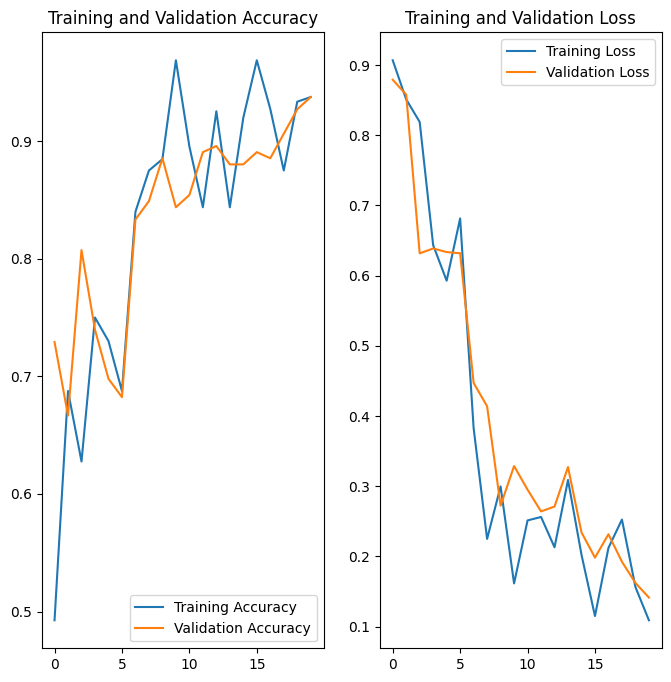

In [20]:
EPOCHS = 20

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

first image to predict
actual label: Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
predicted label: Potato___Late_blight


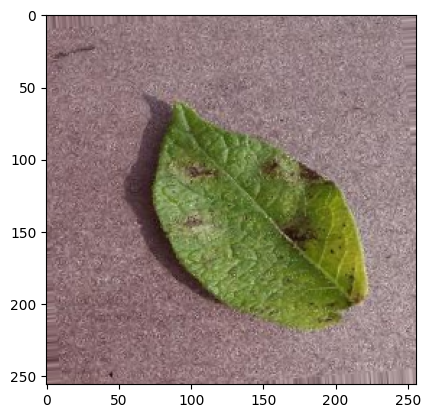

In [21]:
import numpy as np


for image_batch, label_batch in test_generator:
    first_image = image_batch[0]
    first_label = int(label_batch[0])
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(image_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])
    
    break

In [22]:
model.save("../potatoes.h5")